importo las librerias .

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import os
print("Estás en:", os.getcwd())


Estás en: c:\Users\dinam\OneDrive\Escritorio\proyecto EDA


leo los archivos

In [42]:
df_bank = pd.read_csv("archivos/bank-additional.csv", sep=",")

df_customers = pd.read_excel("archivos/customer-details.xlsx")

df_bank.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


leo todas las hojas del archivo xslx y despues las uno .

In [43]:

xls = pd.read_excel("archivos/customer-details.xlsx", sheet_name=None)


df_customers = pd.concat(xls.values(), ignore_index=True)
df_customers.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


2. realizo una limpieza de datos .
- primero reviso columnas y nulos .

In [44]:
# Datos del CSV
print("BANK:")
print(df_bank.info())
print("\nNulos en df_bank:")
print(df_bank.isnull().sum())

# Datos del Excel
print("\nCUSTOMERS:")
print(df_customers.info())
print("\nNulos en df_customers:")
print(df_customers.isnull().sum())

BANK:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  object 
 3   marital         42915 non-null  object 
 4   education       41193 non-null  object 
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  object 
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  object 
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  object 
 16  cons.conf.idx   43000 non-null  object 
 17  euribor3m       33744 non

- segundo renombro las columnas para poder unirlas, y luego las uno por el identificador id .

In [45]:

df_customers.rename(columns={"ID": "id_"}, inplace=True)

# Convertir a string
df_bank["id_"] = df_bank["id_"].astype(str)
df_customers["id_"] = df_customers["id_"].astype(str)

# Merge
df = pd.merge(df_bank, df_customers, on="id_", how="left")


3. Realizo analisis descriptivo .
- primero miro estadisticas generales .

In [46]:
df.describe(include='all')

,Unnamed: 0_x,age,job,marital,education,default,housing,loan,contact,duration,...,date,latitude,longitude,id_,Unnamed: 0_y,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
count,43000.000000,37880.000000,42655,42915,41193,34019.000000,41974.000000,41974.000000,43000,43000.000000,...,42752,43000.000000,43000.000000,43000,43000.000000,43000.000000,43000.000000,43000.000000,43000,43000.000000
unique,NaN,NaN,11,3,7,NaN,NaN,NaN,2,NaN,...,1825,NaN,NaN,43000,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,admin.,MARRIED,university.degree,NaN,NaN,NaN,cellular,NaN,...,28-febrero-2018,NaN,NaN,089b39d8-e4d0-461b-87d4-814d71e0e079,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,10873,25999,12722,NaN,NaN,NaN,27396,NaN,...,95,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,20651.099047,39.977112,NaN,NaN,NaN,0.000088,0.535998,0.155620,NaN,257.739279,...,NaN,36.856697,-95.939067,NaN,7935.478930,93241.200070,1.004791,0.998605,2013-05-12 07:05:06.083720960,16.589698
min,0.000000,17.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.000000,...,NaN,24.396000,-124.997000,NaN,0.000000,5841.000000,0.000000,0.000000,2012-01-01 00:00:00,1.000000
25%,10381.750000,32.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,102.000000,...,NaN,30.614750,-110.494250,NaN,3615.000000,49610.000000,0.000000,0.000000,2012-07-16 00:00:00,9.000000
50%,20642.500000,38.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,179.000000,...,NaN,36.761000,-95.899500,NaN,7222.000000,93050.500000,1.000000,1.000000,2013-03-02 00:00:00,17.000000
75%,30930.250000,47.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,319.000000,...,NaN,43.113250,-81.427750,NaN,11725.250000,136744.500000,2.000000,2.000000,2014-03-29 00:00:00,25.000000
max,41187.000000,98.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,NaN,4918.000000,...,NaN,49.384000,-66.937000,NaN,20114.000000,180802.000000,2.000000,2.000000,2014-12-31 00:00:00,32.000000


- segundo hago analisis por columnas clave .
 - distribucion variables objetivo .
 - por tipo de trabajo .
 - por estado civil .

In [47]:

df['y'].value_counts()


df['job'].value_counts()


df['marital'].value_counts()

marital
MARRIED     25999
SINGLE      12105
DIVORCED     4811
Name: count, dtype: int64

4. represnto las visualizaciones .
- primero grafico de la variables objetivo .

Text(0.5, 1.0, '¿Ha suscrito el cliente un producto?')

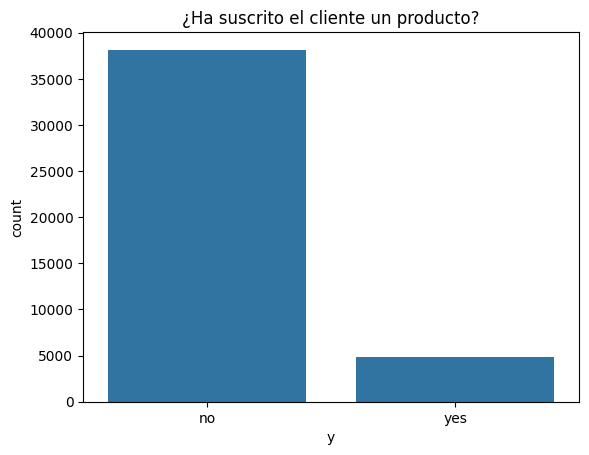

In [48]:
sns.countplot(x='y', data=df)
plt.title('¿Ha suscrito el cliente un producto?')

- lo segundo ingreso por respuesta .

Text(0.5, 1.0, 'Ingreso anual según respuesta del cliente')

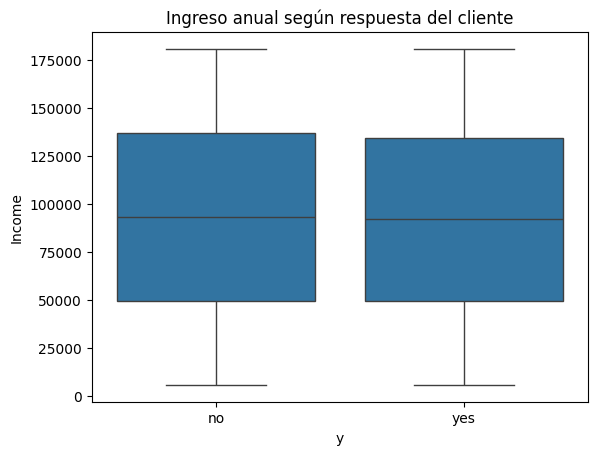

In [49]:
sns.boxplot(x='y', y='Income', data=df)
plt.title('Ingreso anual según respuesta del cliente')

- tercero realizo un histograma de edad .

Text(0, 0.5, 'Frecuencia')

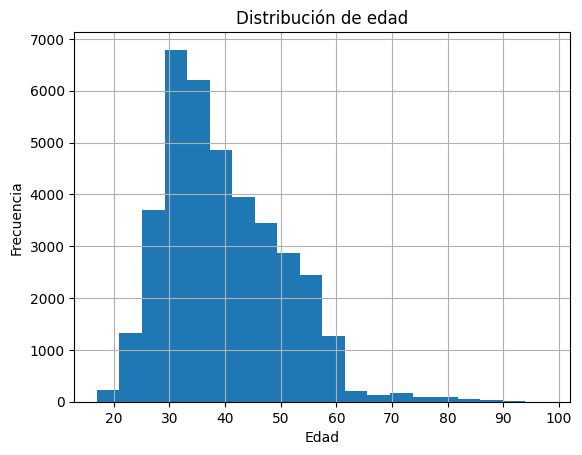

In [50]:
df['age'].hist(bins=20)
plt.title('Distribución de edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

- y lo cuarto y ultimo hago una matriz de correlacion .

Text(0.5, 1.0, 'Correlación entre variables numéricas')

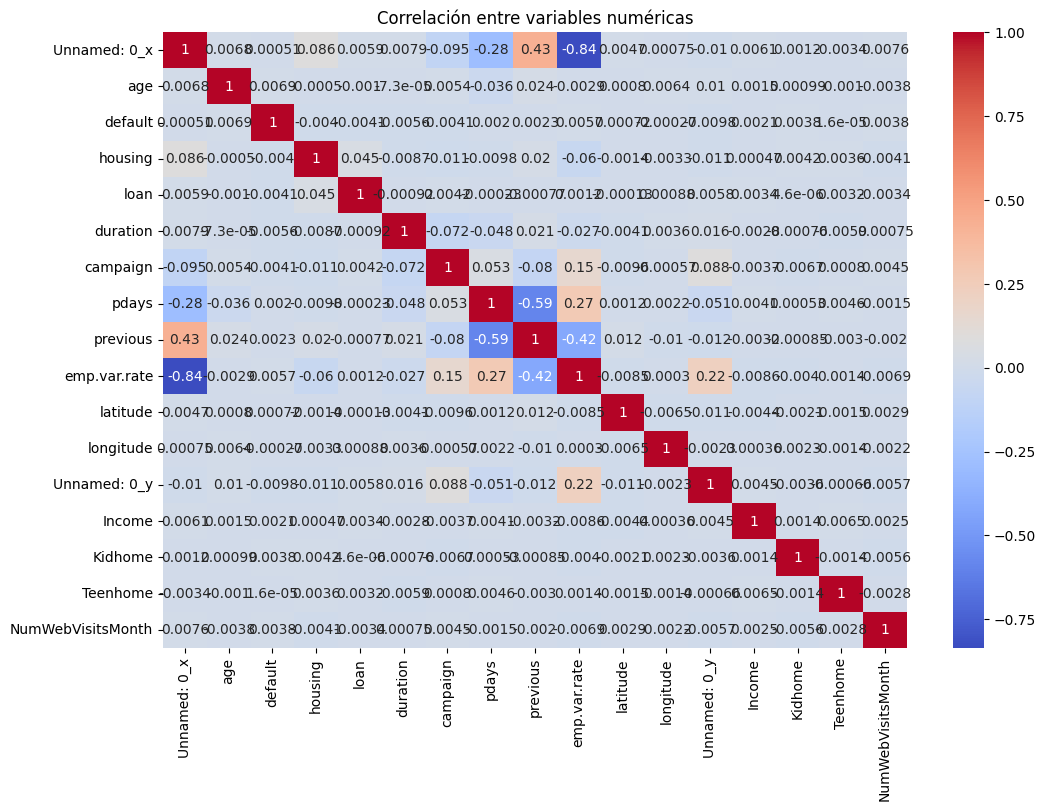

In [51]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')


5. Realizo un informe con las conclusiones .
  Informe EDA: Campaña de Marketing y Clientes del Banco

 1. Limpieza de Datos
- Se cargaron y unieron dos datasets: uno de campañas (CSV) y otro demográfico (Excel).
- Se renombraron columnas y se unificaron hojas de Excel.

 2. Análisis Descriptivo
- La mayoría de clientes no suscribieron un producto.
- Las profesiones más comunes son "admin" y "blue-collar".
- El ingreso medio de quienes suscribieron es ligeramente mayor.

 3. Visualización
- Se usaron gráficos de barras, histogramas y boxplots.
- Hay correlaciones interesantes entre edad, ingresos y respuesta del cliente.

 4. Conclusión
- Los datos muestran patrones útiles para futuras campañas.
- Se podría profundizar en modelos predictivos más adelante.